## Credit Card Behaviour Score

SwipeRight

Submission by Jyoti Yadav and Yash Karnani

1. All Import Statements

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import xgboost as xgb

2. Load Dataset and Exploratory Data Analysis

In [3]:
dev_path='Dev_data_to_be_shared.csv'
df=pd.read_csv(dev_path)

In [4]:
df.head(5)

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48
0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0,221000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,25000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0,86000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0,215000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(96806, 1216)

In [6]:
df.columns

Index(['account_number', 'bad_flag', 'onus_attribute_1',
       'transaction_attribute_1', 'transaction_attribute_2',
       'transaction_attribute_3', 'transaction_attribute_4',
       'transaction_attribute_5', 'transaction_attribute_6',
       'transaction_attribute_7',
       ...
       'bureau_enquiry_47', 'bureau_enquiry_48', 'bureau_enquiry_49',
       'bureau_enquiry_50', 'onus_attribute_43', 'onus_attribute_44',
       'onus_attribute_45', 'onus_attribute_46', 'onus_attribute_47',
       'onus_attribute_48'],
      dtype='object', length=1216)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96806 entries, 0 to 96805
Columns: 1216 entries, account_number to onus_attribute_48
dtypes: float64(1189), int64(27)
memory usage: 898.1 MB


In [8]:
df.describe()

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,onus_attribute_43,onus_attribute_44,onus_attribute_45,onus_attribute_46,onus_attribute_47,onus_attribute_48
count,96806.000000,96806.000000,7.157500e+04,71575.000000,71575.000000,71575.000000,71575.000000,71575.000000,71575.000000,71575.000000,...,94212.0,94212.000000,94212.000000,94212.000000,11610.000000,11610.000000,11610.000000,11610.000000,11610.000000,11610.000000
mean,48403.500000,0.014173,1.542391e+05,9.570769,0.002207,4.092854,77.306435,0.006315,67.043550,0.081034,...,0.0,0.189657,0.044283,7.800673,0.588114,1.497158,0.545650,1.430491,0.121447,0.119208
std,27945.629417,0.118203,1.729925e+05,1513.967595,0.119240,301.580599,3164.987013,0.129545,2516.330899,14.203615,...,0.0,0.597298,0.369451,8.655149,1.059613,1.702795,1.055865,1.728950,0.601256,0.599697
min,1.000000,0.000000,2.500000e+04,0.000000,0.000000,0.000000,-109800.476600,0.000000,-3498.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24202.250000,0.000000,5.900000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
50%,48403.500000,0.000000,1.000000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,5.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,72604.750000,0.000000,1.810000e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,11.000000,1.000000,2.000000,1.000000,2.000000,0.000000,0.000000
max,96806.000000,1.000000,2.800000e+06,398936.791000,25.000000,55000.000000,358986.000000,12.000000,358986.000000,3150.000000,...,0.0,18.000000,14.000000,102.000000,19.000000,38.000000,19.000000,38.000000,15.000000,15.000000


3. Handling Missing Values

In [9]:
df.isnull().sum()

account_number                 0
bad_flag                       0
onus_attribute_1           25231
transaction_attribute_1    25231
transaction_attribute_2    25231
                           ...  
onus_attribute_44          85196
onus_attribute_45          85196
onus_attribute_46          85196
onus_attribute_47          85196
onus_attribute_48          85196
Length: 1216, dtype: int64

In [10]:
null_percentage = df.isnull().mean() * 100
null_percentage

account_number              0.000000
bad_flag                    0.000000
onus_attribute_1           26.063467
transaction_attribute_1    26.063467
transaction_attribute_2    26.063467
                             ...    
onus_attribute_44          88.006942
onus_attribute_45          88.006942
onus_attribute_46          88.006942
onus_attribute_47          88.006942
onus_attribute_48          88.006942
Length: 1216, dtype: float64

In [17]:
columns_to_drop = null_percentage[null_percentage > 50].index

# Drop the identified columns
df = df.drop(columns=columns_to_drop)
# Print the columns removed for reference
print(f"Removed columns with more than 50% null values: {list(columns_to_drop)}")

Removed columns with more than 50% null values: ['bureau_148', 'bureau_433', 'bureau_435', 'bureau_436', 'bureau_437', 'bureau_438', 'bureau_444', 'bureau_445', 'bureau_446', 'bureau_447', 'bureau_448', 'bureau_449', 'bureau_451', 'onus_attribute_43', 'onus_attribute_44', 'onus_attribute_45', 'onus_attribute_46', 'onus_attribute_47', 'onus_attribute_48']


In [18]:
df.fillna(0, inplace=True)
df.isnull().sum()

account_number             0
bad_flag                   0
onus_attribute_1           0
transaction_attribute_1    0
transaction_attribute_2    0
                          ..
bureau_enquiry_47          0
bureau_enquiry_48          0
bureau_enquiry_49          0
bureau_enquiry_50          0
limit_exceeded             0
Length: 1198, dtype: int64

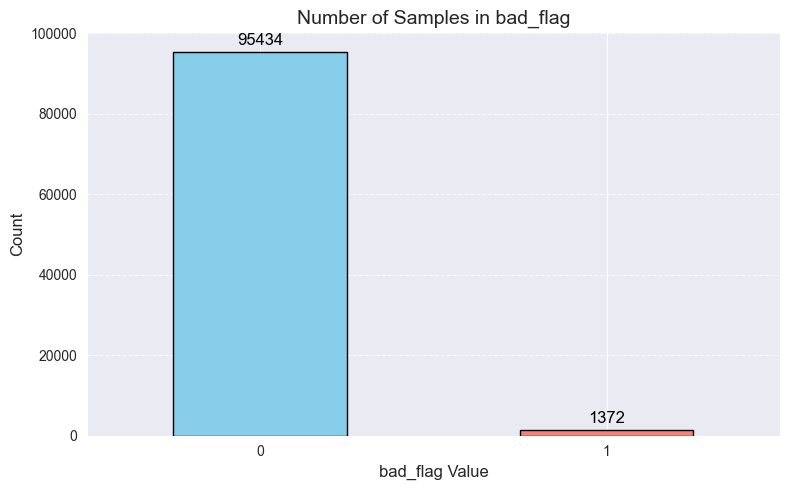

In [19]:
# Count the number of samples for each value in bad_flag
bad_flag_counts = df['bad_flag'].value_counts()

# Plot the counts
plt.figure(figsize=(8, 5))
bars = bad_flag_counts.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')

# Add counts on top of the bars
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate
        height + 0.01 * max(bad_flag_counts),  # Y-coordinate
        f'{int(height)}',  # Text to display
        ha='center', va='bottom', fontsize=12, color='black'
    )

# Customize the plot
plt.title('Number of Samples in bad_flag', fontsize=14)
plt.xlabel('bad_flag Value', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

4. Added a new column that checks if the credit limit has been exceeded

In [20]:
onus_columns = [col for col in df.columns if col.startswith("onus_attribute")]
transaction_columns = [col for col in df.columns if col.startswith("transaction_attribute")]

# Calculate the sum for each group
df["onus_sum"] = df[onus_columns].sum(axis=1)
df["transaction_sum"] = df[transaction_columns].sum(axis=1)

# Add a new column to check if the credit limit is exceeded
df["limit_exceeded"] = (df["onus_sum"] < df["transaction_sum"]).astype('int64')
df.drop(["onus_sum", "transaction_sum"], axis=1, inplace=True)

df.head(5)

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_42,bureau_enquiry_43,bureau_enquiry_44,bureau_enquiry_45,bureau_enquiry_46,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,limit_exceeded
0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,2,0,221000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,0.0,1.0,0.0,0.0,0.0,2.0,3.0,1
2,3,0,25000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,11.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,1
3,4,0,86000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,38.0,0.0,6.0,0.0,0.0,0.0,0.0,30.0,1
4,5,0,215000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96806 entries, 0 to 96805
Columns: 1198 entries, account_number to limit_exceeded
dtypes: float64(1170), int64(28)
memory usage: 884.8 MB


5. Perform MinMax Normalization

In [22]:
selected_cols = [col for col in df.columns if col.startswith(('onus_attribute','transaction_attribute', 'bureau', 'bureau_enquiry'))]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Copy the original DataFrame to preserve the original data
df_normalized = df.copy()

# Normalize the selected columns
df_normalized[selected_cols] = scaler.fit_transform(df[selected_cols])

print(f"Normalization completed on the following columns: {selected_cols}")

Normalization completed on the following columns: ['onus_attribute_1', 'transaction_attribute_1', 'transaction_attribute_2', 'transaction_attribute_3', 'transaction_attribute_4', 'transaction_attribute_5', 'transaction_attribute_6', 'transaction_attribute_7', 'transaction_attribute_8', 'transaction_attribute_9', 'transaction_attribute_10', 'transaction_attribute_11', 'transaction_attribute_12', 'transaction_attribute_13', 'transaction_attribute_14', 'transaction_attribute_15', 'transaction_attribute_16', 'transaction_attribute_17', 'transaction_attribute_18', 'transaction_attribute_19', 'transaction_attribute_20', 'transaction_attribute_21', 'transaction_attribute_22', 'transaction_attribute_23', 'transaction_attribute_24', 'transaction_attribute_25', 'transaction_attribute_26', 'transaction_attribute_27', 'transaction_attribute_28', 'transaction_attribute_29', 'transaction_attribute_30', 'transaction_attribute_31', 'transaction_attribute_32', 'transaction_attribute_33', 'transaction_a

In [23]:
df_normalized.describe()

,account_number,bad_flag,onus_attribute_1,transaction_attribute_1,transaction_attribute_2,transaction_attribute_3,transaction_attribute_4,transaction_attribute_5,transaction_attribute_6,transaction_attribute_7,...,bureau_enquiry_42,bureau_enquiry_43,bureau_enquiry_44,bureau_enquiry_45,bureau_enquiry_46,bureau_enquiry_47,bureau_enquiry_48,bureau_enquiry_49,bureau_enquiry_50,limit_exceeded
count,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,...,96806.000000,96806.000000,96806.000000,96806.000000,96806.000000,96806.0,96806.000000,96806.000000,96806.000000,96806.000000
mean,48403.500000,0.014173,0.040728,0.000018,0.000065,0.000055,0.234345,0.000389,0.009787,0.000019,...,0.020380,0.048827,0.012526,0.026212,0.010318,0.0,0.010254,0.003078,0.074428,0.757236
std,27945.629417,0.118203,0.058370,0.003263,0.004101,0.004715,0.005806,0.009285,0.005970,0.003877,...,0.036896,0.052909,0.037804,0.044122,0.028329,0.0,0.032780,0.026038,0.084616,0.428756
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,24202.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.234223,0.000000,0.009650,0.000000,...,0.000000,0.010453,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.009804,1.000000
50%,48403.500000,0.000000,0.024643,0.000000,0.000000,0.000000,0.234223,0.000000,0.009650,0.000000,...,0.000000,0.031359,0.000000,0.007463,0.000000,0.0,0.000000,0.000000,0.049020,1.000000
75%,72604.750000,0.000000,0.051786,0.000000,0.000000,0.000000,0.234223,0.000000,0.009650,0.000000,...,0.033898,0.069686,0.000000,0.037313,0.000000,0.0,0.000000,0.000000,0.107843,1.000000
max,96806.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000


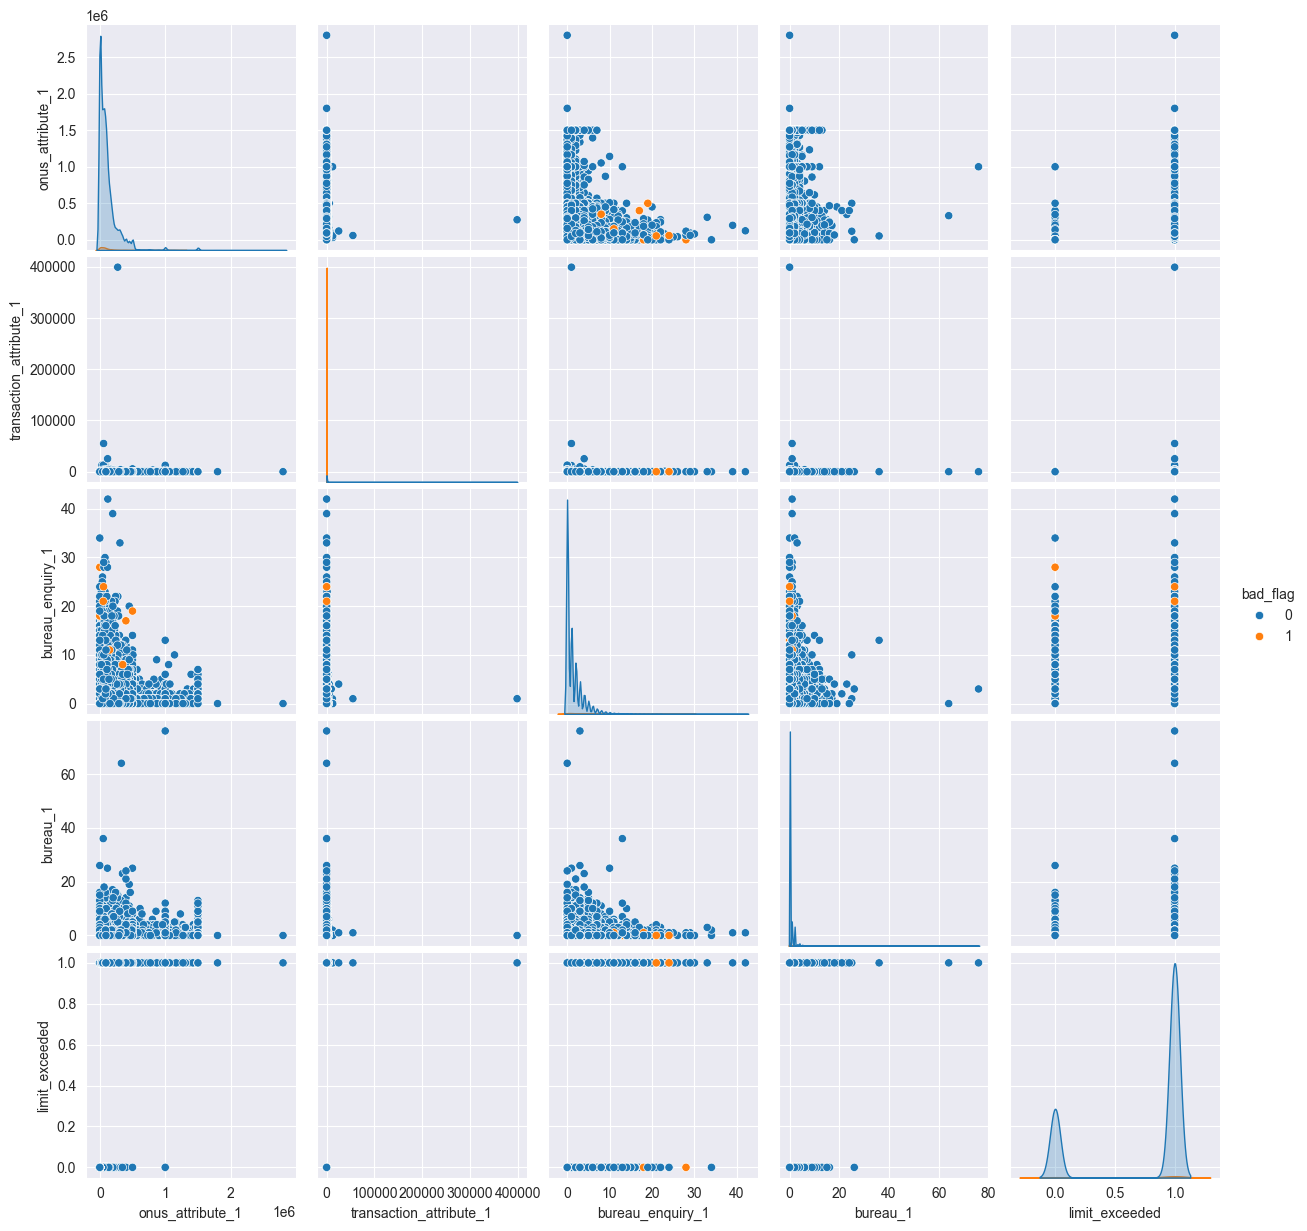

In [24]:
selected_columns = ['onus_attribute_1', 'transaction_attribute_1', 'bureau_enquiry_1', 'bureau_1', 'limit_exceeded']

# Create the pairplot
sns.pairplot(df[selected_columns + ['bad_flag']], hue='bad_flag')

# Show the plot
plt.show()

6. Apply UnderSampler on majority class data

In [25]:
# Extract features (X) and target (y) from df_normalized
X = df_normalized.drop(columns=['account_number','bad_flag'])
y = df_normalized['bad_flag']

# Initialize the undersampler
undersampler = RandomUnderSampler(sampling_strategy=0.5, random_state=12)

# Apply undersampling to balance the dataset
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Combine the resampled features and target into a new dataframe
df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='bad_flag')], axis=1)

# Check the distribution of the classes in the resampled dataset
print("Resampled class distribution after UnderSampler:")
print(df_resampled['bad_flag'].value_counts())

Resampled class distribution after UnderSampler:
bad_flag
0    2744
1    1372
Name: count, dtype: int64


7. Test and train split (80:20)

In [26]:
X_resampled = df_resampled.drop(columns=['bad_flag'])
y_resampled = df_resampled['bad_flag']

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=12)

# Check the shape of the resulting splits
print(f"Training Data Features: {X_train.shape}")
print(f"Testing Data Features: {X_test.shape}")
print(f"Training Data Target: {y_train.shape}")
print(f"Testing Data Target: {y_test.shape}")


Training Data Features: (3292, 1196)
Testing Data Features: (824, 1196)
Training Data Target: (3292,)
Testing Data Target: (824,)


8. Load Logistic Regression Model and perform hyperparameter tuning

In [27]:
# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=12, max_iter=2000, class_weight='balanced', solver='liblinear')

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_pred_prob = log_reg_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (1)

In [28]:
# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

Accuracy Score: 0.7390776699029126
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.72      0.79       559
           1       0.57      0.78      0.66       265

    accuracy                           0.74       824
   macro avg       0.72      0.75      0.72       824
weighted avg       0.77      0.74      0.75       824

ROC-AUC Score: 0.8261450703749958


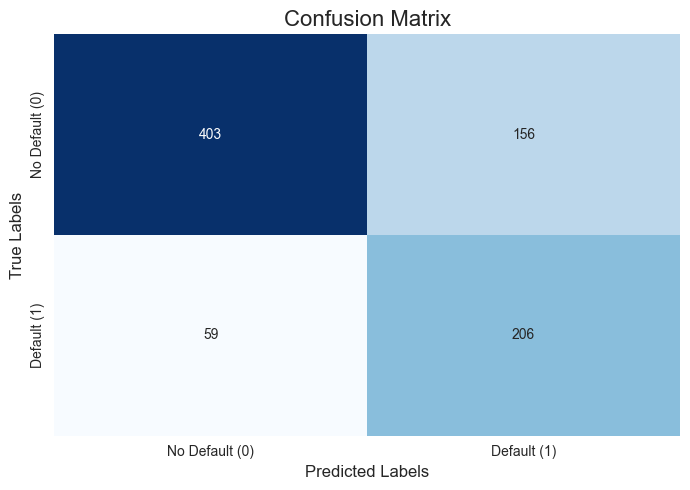

In [29]:
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()

plt.show()

Accuracy Score: 0.7390776699029126

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.72      0.79       559
           1       0.57      0.78      0.66       265

    accuracy                           0.74       824
   macro avg       0.72      0.75      0.72       824
weighted avg       0.77      0.74      0.75       824


ROC-AUC Score: 0.8262395787626151


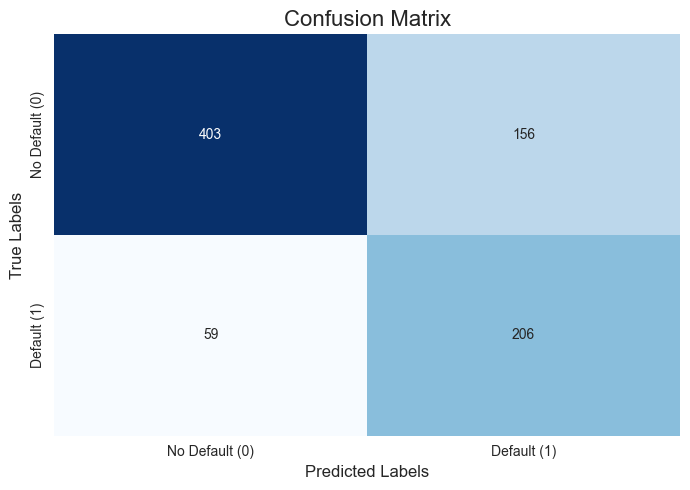

In [30]:
# Define the Logistic Regression model with the best hyperparameters
final_model = LogisticRegression(
    C=1,
    solver='newton-cg',
    penalty='l2',
    max_iter=1000,
    class_weight='balanced',
    random_state=97
)

# Fit the model to the training data
final_model.fit(X_train, y_train)

# Evaluate the model
y_pred = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

cm2 = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()


9. Load XGBoost model and perform hyperparameter tuning

Accuracy Score: 0.7548543689320388

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       559
           1       0.61      0.66      0.63       265

    accuracy                           0.75       824
   macro avg       0.72      0.73      0.72       824
weighted avg       0.76      0.75      0.76       824


ROC-AUC Score: 0.8099436324973841


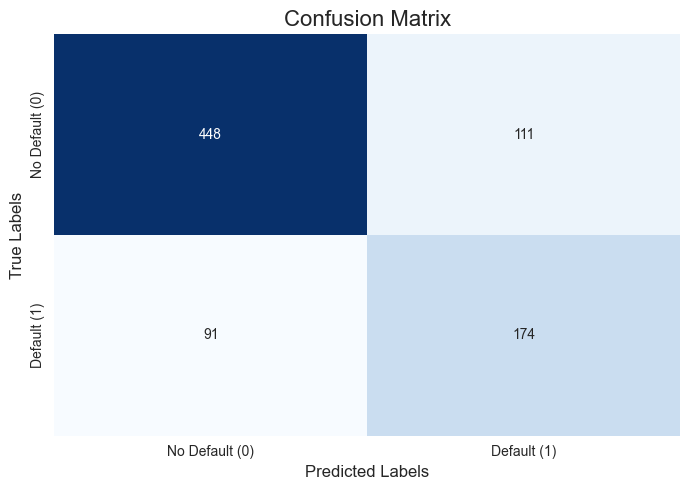

In [33]:
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

cm2 = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
# # Define the hyperparameters grid
# param_grid = {
#     'n_estimators': [300, 500, 1000],
#     'learning_rate': [0.01, 0.05],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.7],
#     'colsample_bytree': [0.7]
# }
#
# # Initialize GridSearchCV
# grid_search = GridSearchCV(estimator=xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=12,scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])), param_grid=param_grid, scoring='accuracy', cv=2, n_jobs=-1, verbose=2)
#
# # Fit the grid search
# grid_search.fit(X_train, y_train)
#
# # Best parameters and score from grid search
# print("Best Hyperparameters from GridSearchCV:")
# print(grid_search.best_params_)
# print("Best Cross-validation Accuracy: {:.4f}".format(grid_search.best_score_))
#
# # Evaluate the best model on the test set
# best_xgb_model = grid_search.best_estimator_
# y_pred = best_xgb_model.predict(X_test)
# y_pred_prob = best_xgb_model.predict_proba(X_test)[:, 1]
#
# # Display the evaluation metrics
# print("Accuracy Score:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))
# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_pred))
# print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

Accuracy Score: 0.7682038834951457

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.77      0.82       559
           1       0.61      0.76      0.68       265

    accuracy                           0.77       824
   macro avg       0.74      0.77      0.75       824
weighted avg       0.79      0.77      0.77       824


ROC-AUC Score: 0.833786748573936


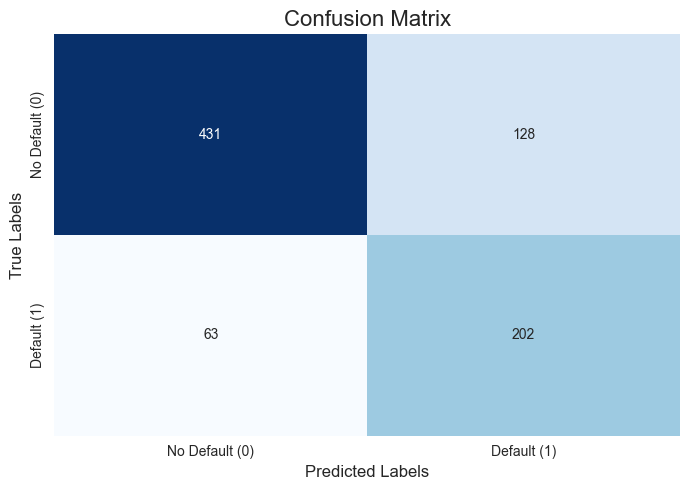

In [32]:
# Define the XGBoost model with the best hyperparameters
final_xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=12,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

# Fit the model to the training data
final_xgb_model.fit(X_train, y_train)

# Evaluate the model
y_pred = final_xgb_model.predict(X_test)
y_pred_prob = final_xgb_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

cm2 = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
# Get feature importances from the trained XGBoost model
feature_importances = xgb_model.feature_importances_

# Create a DataFrame to pair feature names with their importance values
features = X_train.columns
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
431,transaction_attribute_431,0.028269
1128,onus_attribute_26,0.020089
1103,bureau_452,0.011013
1104,onus_attribute_2,0.010649
648,transaction_attribute_648,0.009643
...,...,...
449,transaction_attribute_449,0.000000
450,transaction_attribute_450,0.000000
451,transaction_attribute_451,0.000000
452,transaction_attribute_452,0.000000


10. Train and test split (80:20) and apply SMOTE instead of UnderSampler.


In [35]:
X = df_normalized.drop(columns=['account_number', 'bad_flag'])
y = df_normalized['bad_flag']

# Split the data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=12)

# Check the shape of the resulting splits
print(f"Training Data Features: {X_train.shape}")
print(f"Testing Data Features: {X_test.shape}")
print(f"Training Data Target: {y_train.shape}")
print(f"Testing Data Target: {y_test.shape}")


Training Data Features: (67764, 1196)
Testing Data Features: (29042, 1196)
Training Data Target: (67764,)
Testing Data Target: (29042,)


In [36]:
# Initialize SMOTE for oversampling the minority class
smote = SMOTE(sampling_strategy='auto', random_state=12)

# Apply SMOTE to balance the dataset by oversampling the minority class
X_resampled, y_resampled = smote.fit_resample(X_train,y_train)
X_resampled, y_resampled

(        onus_attribute_1  transaction_attribute_1  transaction_attribute_2  \
 0               0.046429                      0.0                      0.0   
 1               0.015357                      0.0                      0.0   
 2               0.040357                      0.0                      0.0   
 3               0.075000                      0.0                      0.0   
 4               0.008929                      0.0                      0.0   
 ...                  ...                      ...                      ...   
 133581          0.021651                      0.0                      0.0   
 133582          0.046199                      0.0                      0.0   
 133583          0.026613                      0.0                      0.0   
 133584          0.020350                      0.0                      0.0   
 133585          0.009107                      0.0                      0.0   
 
         transaction_attribute_3  transaction_attr

11. Load, train and predict using both models

Accuracy Score: 0.796501618345844

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.80      0.89     28641
           1       0.04      0.64      0.08       401

    accuracy                           0.80     29042
   macro avg       0.52      0.72      0.48     29042
weighted avg       0.98      0.80      0.87     29042


ROC-AUC Score: 0.7853342447797966


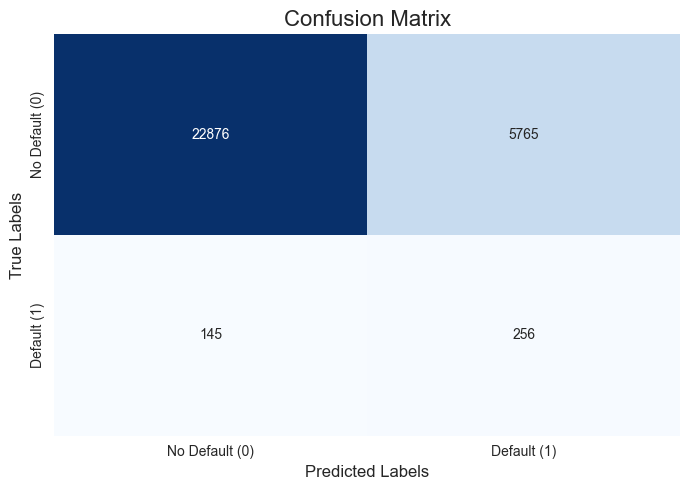

In [37]:
# Define the Logistic Regression model with the best hyperparameters
final_model = LogisticRegression(
    C=1,
    solver='newton-cg',
    penalty='l2',
    max_iter=1000,
    class_weight='balanced',
    random_state=97
)

# Fit the model to the training data
final_model.fit(X_resampled, y_resampled)

# Evaluate the model
y_pred = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

cm2 = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()


In [32]:
# Define the hyperparameters grid
param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [3, 5, 7],
    'min_child_weight': [3, 5],
    'subsample': [0.7],
    'colsample_bytree': [0.7]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=12,scale_pos_weight=len(y_resampled[y_resampled == 0]) / len(y_resampled[y_resampled == 1])), param_grid=param_grid, scoring={'accuracy': 'accuracy', 'f1': 'f1'},refit='f1', cv=2, n_jobs=-1, verbose=2)

# Fit the grid search
grid_search.fit(X_resampled, y_resampled)

# Best parameters and score from grid search
print("Best Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)
print("Best Cross-validation Accuracy: {:.4f}".format(grid_search.best_score_))

# Evaluate the best model on the test set
best_xgb_model = grid_search.best_estimator_
y_pred = best_xgb_model.predict(X_test)
y_pred_prob = best_xgb_model.predict_proba(X_test)[:, 1]

# Display the evaluation metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

Fitting 2 folds for each of 72 candidates, totalling 144 fits


C:\Users\sharv\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
1 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sharv\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\sharv\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
  File "C:\Users\sharv\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\sklearn.py", lin

Best Hyperparameters from GridSearchCV:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 1000, 'subsample': 0.7}
Best Cross-validation Accuracy: 0.9923
Accuracy Score: 0.9861924109909785

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     28641
           1       0.50      0.00      0.00       401

    accuracy                           0.99     29042
   macro avg       0.74      0.50      0.50     29042
weighted avg       0.98      0.99      0.98     29042


Confusion Matrix:
[[28640     1]
 [  400     1]]

ROC-AUC Score: 0.8139843819451754


Accuracy Score: 0.887645478961504

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     28641
           1       0.06      0.48      0.11       401

    accuracy                           0.89     29042
   macro avg       0.53      0.69      0.52     29042
weighted avg       0.98      0.89      0.93     29042


ROC-AUC Score: 0.8163980433330625


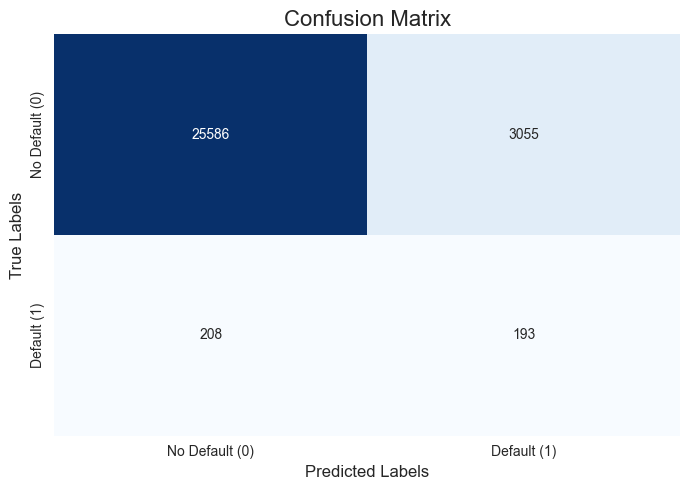

In [41]:
# Define the XGBoost model with the best hyperparameters
final_xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=12,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

# Fit the model to the training data
final_xgb_model.fit(X_train, y_train)

# Evaluate the model
y_pred = final_xgb_model.predict(X_test)
y_pred_prob = final_xgb_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

cm2 = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

Accuracy Score: 0.853488051787067

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     28641
           1       0.05      0.58      0.10       401

    accuracy                           0.85     29042
   macro avg       0.52      0.72      0.51     29042
weighted avg       0.98      0.85      0.91     29042


ROC-AUC Score: 0.8189453568341635


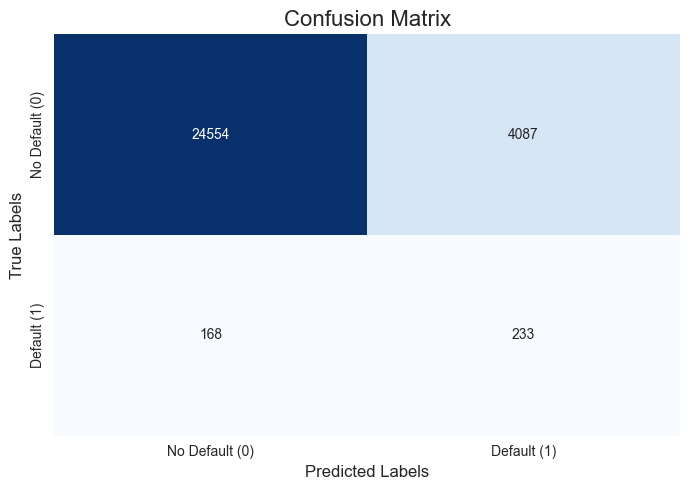

In [43]:
# Define the XGBoost model with the best hyperparameters
final_xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=12,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

# Fit the model to the training data
final_xgb_model.fit(X_train, y_train)

# Evaluate the model
y_pred = final_xgb_model.predict(X_test)
y_pred_prob = final_xgb_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

cm2 = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

Accuracy Score: 0.8512499139177743

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     28641
           1       0.05      0.58      0.10       401

    accuracy                           0.85     29042
   macro avg       0.52      0.72      0.51     29042
weighted avg       0.98      0.85      0.91     29042


ROC-AUC Score: 0.8141506852261127


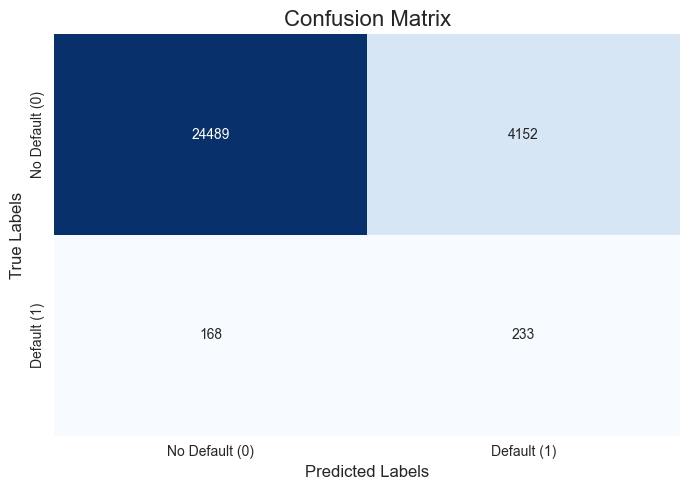

In [57]:
# Define the XGBoost model with the best hyperparameters
final_xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=12,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

# Fit the model to the training data
final_xgb_model.fit(X_train, y_train)

# Evaluate the model
y_pred = final_xgb_model.predict(X_test)
y_pred_prob = final_xgb_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))

cm2 = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.tight_layout()
plt.show()

12. Perform Cross Validation to check for Overfitting

In [54]:
# Perform cross-validation
cv_scores = cross_val_score(final_xgb_model, X_resampled, y_resampled, cv=3, scoring='accuracy', n_jobs=-1)

# Print the cross-validation results
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Cross-Validation Accuracy: {:.4f}".format(cv_scores.mean()))
print("Standard Deviation of CV Accuracy: {:.4f}".format(cv_scores.std()))


Cross-Validation Accuracy Scores: [0.97840695 0.8997151  0.90036349]
Mean Cross-Validation Accuracy: 0.9262
Standard Deviation of CV Accuracy: 0.0369


In [55]:
# Get feature importances from the trained XGBoost model
feature_importances = xgb_model.feature_importances_

# Create a DataFrame to pair feature names with their importance values
features = X_train.columns
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df


,Feature,Importance
1119,onus_attribute_4,0.020081
1141,onus_attribute_26,0.019843
765,bureau_101,0.012622
537,transaction_attribute_537,0.011663
431,transaction_attribute_431,0.011556
...,...,...
458,transaction_attribute_458,0.000000
459,transaction_attribute_459,0.000000
460,transaction_attribute_460,0.000000
461,transaction_attribute_461,0.000000


## Prediction on Validation Data

13. Prediction on Validation Data and storing it in output.csv

In [93]:
val_data='validation_data_to_be_shared.csv'
df_val=pd.read_csv(val_data)

In [94]:
df_val.shape

(41792, 1215)

In [95]:
df_val.columns

Index(['account_number', 'onus_attribute_1', 'transaction_attribute_1',
       'transaction_attribute_2', 'transaction_attribute_3',
       'transaction_attribute_4', 'transaction_attribute_5',
       'transaction_attribute_6', 'transaction_attribute_7',
       'transaction_attribute_8',
       ...
       'bureau_enquiry_47', 'bureau_enquiry_48', 'bureau_enquiry_49',
       'bureau_enquiry_50', 'onus_attribute_43', 'onus_attribute_44',
       'onus_attribute_45', 'onus_attribute_46', 'onus_attribute_47',
       'onus_attribute_48'],
      dtype='object', length=1215)

In [96]:
df_val.isnull().sum()

account_number                 0
onus_attribute_1           10990
transaction_attribute_1    10990
transaction_attribute_2    10990
transaction_attribute_3    10990
                           ...  
onus_attribute_44          36789
onus_attribute_45          36789
onus_attribute_46          36789
onus_attribute_47          36789
onus_attribute_48          36789
Length: 1215, dtype: int64

In [97]:
df_val.fillna(0, inplace=True)
df_val.isnull().sum()

account_number             0
onus_attribute_1           0
transaction_attribute_1    0
transaction_attribute_2    0
transaction_attribute_3    0
                          ..
onus_attribute_44          0
onus_attribute_45          0
onus_attribute_46          0
onus_attribute_47          0
onus_attribute_48          0
Length: 1215, dtype: int64

In [98]:
onus_columns = [col for col in df_val.columns if col.startswith("onus_attribute")]
transaction_columns = [col for col in df_val.columns if col.startswith("transaction_attribute")]

# Calculate the sum for each group
df_val["onus_sum"] = df_val[onus_columns].sum(axis=1)
df_val["transaction_sum"] = df_val[transaction_columns].sum(axis=1)

# Add a new column to check if the credit limit is exceeded
df_val["limit_exceeded"] = (df_val["onus_sum"] < df_val["transaction_sum"]).astype('int64')
df_val.drop(["onus_sum", "transaction_sum"], axis=1, inplace=True)

df_val.columns

Index(['account_number', 'onus_attribute_1', 'transaction_attribute_1',
       'transaction_attribute_2', 'transaction_attribute_3',
       'transaction_attribute_4', 'transaction_attribute_5',
       'transaction_attribute_6', 'transaction_attribute_7',
       'transaction_attribute_8',
       ...
       'bureau_enquiry_48', 'bureau_enquiry_49', 'bureau_enquiry_50',
       'onus_attribute_43', 'onus_attribute_44', 'onus_attribute_45',
       'onus_attribute_46', 'onus_attribute_47', 'onus_attribute_48',
       'limit_exceeded'],
      dtype='object', length=1216)

In [99]:
selected_cols = [col for col in df_val.columns if col.startswith(('onus_attribute','transaction_attribute', 'bureau', 'bureau_enquiry'))]
# Initialize the MinMaxScaler
scaler = MinMaxScaler()
# Copy the original DataFrame to preserve the original data
df_normalized_val = df_val.copy()
# Normalize the selected columns
df_normalized_val[selected_cols] = scaler.fit_transform(df_val[selected_cols])
print(f"Normalization completed")

Normalization completed


In [100]:
X_val = df_val.drop(columns=['account_number'])

In [101]:
y_val_pred = final_xgb_model.predict(X_val)
y_val_pred_prob = final_xgb_model.predict_proba(X_val)[:, 1]
y_val_pred,y_val_pred_prob

(array([0, 0, 0, ..., 0, 0, 0]),
 array([0.02430915, 0.03800275, 0.01321729, ..., 0.05610112, 0.04387337,
        0.02991178], dtype=float32))

In [104]:
# Create a new DataFrame with the desired columns
new_df = pd.DataFrame({'account_number': df_val.account_number, 'bad_flag': y_val_pred_prob})

# Save the DataFrame to a CSV file
new_df.to_csv('output_file.csv', index=False)

EOF